In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

print("pandas:", pd.__version__)
print("numpy :", np.__version__)

pandas: 2.0.3
numpy : 1.23.0


In [35]:
DATA_DIR = Path("data")

FILES = {
    "gold": DATA_DIR / "gold_1h_raw.csv",
    "dxy": DATA_DIR / "dxy_1h_raw.csv",
    "vix": DATA_DIR / "vix_1h_raw.csv",
    "sp500": DATA_DIR / "sp500_1h_raw.csv"
}

for name, path in FILES.items():
    print(name, "->", path, "| exists =", path.exists())

gold -> data\gold_1h_raw.csv | exists = True
dxy -> data\dxy_1h_raw.csv | exists = True
vix -> data\vix_1h_raw.csv | exists = True
sp500 -> data\sp500_1h_raw.csv | exists = True


In [36]:
def load_market_csv(path):
    df = pd.read_csv(
        path,
        index_col=0,
        parse_dates=True
    )
    
    df = df.sort_index()
    
    # Remove duplicate timestamps
    df = df[~df.index.duplicated(keep="last")]
    
    return df

In [4]:
data = {}

for name, path in FILES.items():
    
    df = load_market_csv(path)
    
    data[name] = df
    
    print(
        f"{name:6s} | "
        f"rows={len(df):5d} | "
        f"start={df.index.min()} | "
        f"end={df.index.max()}"
    )

gold   | rows=  557 | start=2026-08-20 04:00:00+00:00 | end=2026-09-24 12:00:00+00:00
dxy    | rows=  580 | start=2026-08-20 04:00:00+00:00 | end=2026-09-24 12:00:00+00:00
vix    | rows=  407 | start=2026-08-14 07:00:00+00:00 | end=2026-09-24 12:00:00+00:00
sp500  | rows=  210 | start=2026-08-12 13:30:00+00:00 | end=2026-09-23 19:30:00+00:00


In [37]:
for name, df in data.items():
    
    print("\n", "=" * 60)
    print(name.upper())
    print("=" * 60)
    
    print(df.columns.tolist())


GOLD
['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']

DXY
['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']

VIX
['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']

SP500
['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']


In [38]:
def prepare_market_data(df, prefix):
    
    df = df.copy()
    
    # Remove unnecessary column
    if "Adj Close" in df.columns:
        df = df.drop(columns=["Adj Close"])
    
    # Rename columns
    df = df.rename(
        columns={
            col: f"{prefix}_{col}"
            for col in df.columns
        }
    )
    
    return df

In [39]:
gold = prepare_market_data(
    data["gold"],
    "GOLD"
)

dxy = prepare_market_data(
    data["dxy"],
    "DXY"
)

vix = prepare_market_data(
    data["vix"],
    "VIX"
)

sp500 = prepare_market_data(
    data["sp500"],
    "SP500"
)

In [40]:
print(gold.columns.tolist())
print(dxy.columns.tolist())
print(vix.columns.tolist())
print(sp500.columns.tolist())

['GOLD_Close', 'GOLD_High', 'GOLD_Low', 'GOLD_Open', 'GOLD_Volume']
['DXY_Close', 'DXY_High', 'DXY_Low', 'DXY_Open', 'DXY_Volume']
['VIX_Close', 'VIX_High', 'VIX_Low', 'VIX_Open', 'VIX_Volume']
['SP500_Close', 'SP500_High', 'SP500_Low', 'SP500_Open', 'SP500_Volume']


In [9]:
for name, df in {
    "GOLD": gold,
    "DXY": dxy,
    "VIX": vix,
    "SP500": sp500
}.items():
    
    print("\n", name)
    print(df.dtypes)


 GOLD
GOLD_Close     float64
GOLD_High      float64
GOLD_Low       float64
GOLD_Open      float64
GOLD_Volume      int64
dtype: object

 DXY
DXY_Close     float64
DXY_High      float64
DXY_Low       float64
DXY_Open      float64
DXY_Volume      int64
dtype: object

 VIX
VIX_Close     float64
VIX_High      float64
VIX_Low       float64
VIX_Open      float64
VIX_Volume      int64
dtype: object

 SP500
SP500_Close     float64
SP500_High      float64
SP500_Low       float64
SP500_Open      float64
SP500_Volume      int64
dtype: object


In [41]:
datasets = {
    "GOLD": gold,
    "DXY": dxy,
    "VIX": vix,
    "SP500": sp500
}

for name, df in datasets.items():
    
    for col in df.columns:
        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

In [11]:
for name, df in datasets.items():
    
    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)
    
    missing = df.isna().sum()
    
    print(
        missing[missing > 0]
    )


GOLD
Series([], dtype: int64)

DXY
Series([], dtype: int64)

VIX
Series([], dtype: int64)

SP500
Series([], dtype: int64)


In [42]:
def check_ohlc(df, prefix):
    
    high = df[f"{prefix}_High"]
    low = df[f"{prefix}_Low"]
    open_ = df[f"{prefix}_Open"]
    close = df[f"{prefix}_Close"]
    
    invalid = (
        (high < open_) |
        (high < close) |
        (high < low) |
        (low > open_) |
        (low > close) |
        (low > high)
    )
    
    return invalid.sum()

In [13]:
for prefix, df in [
    ("GOLD", gold),
    ("DXY", dxy),
    ("VIX", vix),
    ("SP500", sp500)
]:
    
    print(
        prefix,
        "invalid OHLC rows =",
        check_ohlc(df, prefix)
    )

GOLD invalid OHLC rows = 0
DXY invalid OHLC rows = 0
VIX invalid OHLC rows = 0
SP500 invalid OHLC rows = 0


In [43]:
for name, df in datasets.items():
    
    duplicates = df.index.duplicated().sum()
    
    print(
        f"{name}: duplicates = {duplicates}"
    )

GOLD: duplicates = 0
DXY: duplicates = 0
VIX: duplicates = 0
SP500: duplicates = 0


In [44]:
for name, df in datasets.items():
    
    print("\n", name)
    print("Timezone:", df.index.tz)
    print("First:", df.index[:3])


 GOLD
Timezone: UTC
First: DatetimeIndex(['2026-08-20 04:00:00+00:00', '2026-08-20 05:00:00+00:00',
               '2026-08-20 06:00:00+00:00'],
              dtype='datetime64[ns, UTC]', name='Datetime', freq=None)

 DXY
Timezone: UTC
First: DatetimeIndex(['2026-08-20 04:00:00+00:00', '2026-08-20 05:00:00+00:00',
               '2026-08-20 06:00:00+00:00'],
              dtype='datetime64[ns, UTC]', name='Datetime', freq=None)

 VIX
Timezone: UTC
First: DatetimeIndex(['2026-08-14 07:00:00+00:00', '2026-08-14 08:00:00+00:00',
               '2026-08-14 09:00:00+00:00'],
              dtype='datetime64[ns, UTC]', name='Datetime', freq=None)

 SP500
Timezone: UTC
First: DatetimeIndex(['2026-08-12 13:30:00+00:00', '2026-08-12 14:30:00+00:00',
               '2026-08-12 15:30:00+00:00'],
              dtype='datetime64[ns, UTC]', name='Datetime', freq=None)


In [45]:
def normalize_timezone(df):
    
    df = df.copy()
    
    if df.index.tz is not None:
        df.index = df.index.tz_convert("UTC").tz_localize(None)
    
    return df

In [46]:
for name, df in {
    "GOLD": gold,
    "DXY": dxy,
    "VIX": vix,
    "SP500": sp500
}.items():
    
    print(
        f"{name:6s} | "
        f"{df.index.min()} → {df.index.max()} | "
        f"{len(df)} rows"
    )

GOLD   | 2026-08-20 04:00:00+00:00 → 2026-09-24 12:00:00+00:00 | 557 rows
DXY    | 2026-08-20 04:00:00+00:00 → 2026-09-24 12:00:00+00:00 | 580 rows
VIX    | 2026-08-14 07:00:00+00:00 → 2026-09-24 12:00:00+00:00 | 407 rows
SP500  | 2026-08-12 13:30:00+00:00 → 2026-09-23 19:30:00+00:00 | 210 rows


In [47]:
market_inner = pd.concat(
    [
        gold,
        dxy,
        vix,
        sp500
    ],
    axis=1,
    join="inner"
)

In [48]:
print("Rows:", len(market_inner))
print("Columns:", len(market_inner.columns))

Rows: 0
Columns: 20


In [49]:
print(
    market_inner.isna().sum()
)

GOLD_Close      0.0
GOLD_High       0.0
GOLD_Low        0.0
GOLD_Open       0.0
GOLD_Volume     0.0
DXY_Close       0.0
DXY_High        0.0
DXY_Low         0.0
DXY_Open        0.0
DXY_Volume      0.0
VIX_Close       0.0
VIX_High        0.0
VIX_Low         0.0
VIX_Open        0.0
VIX_Volume      0.0
SP500_Close     0.0
SP500_High      0.0
SP500_Low       0.0
SP500_Open      0.0
SP500_Volume    0.0
dtype: float64


In [50]:
print(
    "Total NaN:",
    market_inner.isna().sum().sum()
)

Total NaN: 0.0


In [51]:
market_inner.head()

,GOLD_Close,GOLD_High,GOLD_Low,GOLD_Open,GOLD_Volume,DXY_Close,DXY_High,DXY_Low,DXY_Open,DXY_Volume,VIX_Close,VIX_High,VIX_Low,VIX_Open,VIX_Volume,SP500_Close,SP500_High,SP500_Low,SP500_Open,SP500_Volume
Datetime,,,,,,,,,,,,,,,,,,,,


In [52]:
market_inner.tail()

,GOLD_Close,GOLD_High,GOLD_Low,GOLD_Open,GOLD_Volume,DXY_Close,DXY_High,DXY_Low,DXY_Open,DXY_Volume,VIX_Close,VIX_High,VIX_Low,VIX_Open,VIX_Volume,SP500_Close,SP500_High,SP500_Low,SP500_Open,SP500_Volume
Datetime,,,,,,,,,,,,,,,,,,,,


In [53]:
rows_before = {
    "GOLD": len(gold),
    "DXY": len(dxy),
    "VIX": len(vix),
    "SP500": len(sp500)
}

rows_after = len(market_inner)

print("Rows after inner merge:", rows_after)

for name, rows in rows_before.items():
    print(
        f"{name}: {rows} → {rows_after}"
    )

Rows after inner merge: 0
GOLD: 557 → 0
DXY: 580 → 0
VIX: 407 → 0
SP500: 210 → 0


In [54]:
time_diff = (
    market_inner.index.to_series()
    .diff()
    .dropna()
)

print(
    time_diff.value_counts().head(10)
)

Series([], Name: count, dtype: int64)


In [55]:
expected = pd.Timedelta(hours=1)

gaps = time_diff[
    time_diff > expected
]

print("Number of gaps:", len(gaps))

print(
    gaps.head(20)
)

Number of gaps: 0
Series([], Name: Datetime, dtype: timedelta64[ns])


In [56]:
quality_report = pd.DataFrame({
    "rows": [
        len(gold),
        len(dxy),
        len(vix),
        len(sp500),
        len(market_inner)
    ],
    "columns": [
        len(gold.columns),
        len(dxy.columns),
        len(vix.columns),
        len(sp500.columns),
        len(market_inner.columns)
    ],
    "missing_values": [
        gold.isna().sum().sum(),
        dxy.isna().sum().sum(),
        vix.isna().sum().sum(),
        sp500.isna().sum().sum(),
        market_inner.isna().sum().sum()
    ],
    "duplicate_timestamps": [
        gold.index.duplicated().sum(),
        dxy.index.duplicated().sum(),
        vix.index.duplicated().sum(),
        sp500.index.duplicated().sum(),
        market_inner.index.duplicated().sum()
    ]
}, index=[
    "GOLD",
    "DXY",
    "VIX",
    "SP500",
    "MERGED"
])

quality_report

,rows,columns,missing_values,duplicate_timestamps
GOLD,557,5,0.0,0
DXY,580,5,0.0,0
VIX,407,5,0.0,0
SP500,210,5,0.0,0
MERGED,0,20,0.0,0


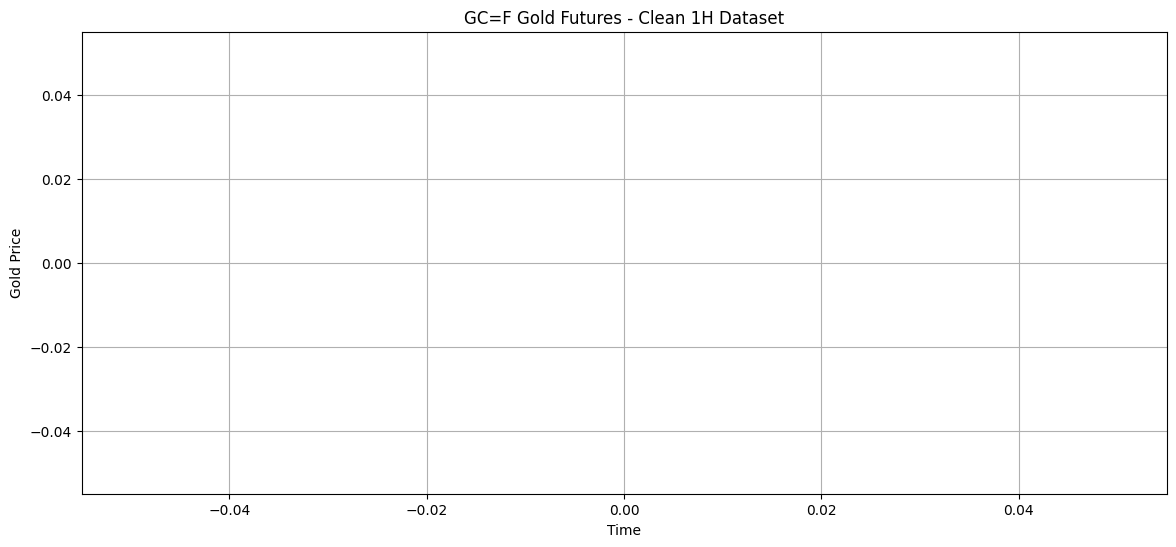

In [57]:
plt.figure(figsize=(14, 6))

plt.plot(
    market_inner.index,
    market_inner["GOLD_Close"]
)

plt.title("GC=F Gold Futures - Clean 1H Dataset")
plt.xlabel("Time")
plt.ylabel("Gold Price")

plt.grid(True)
plt.show()

In [58]:
CLEAN_DIR = Path("clean")
CLEAN_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [59]:
clean_file = CLEAN_DIR / "market_data_1h_clean.csv"

market_inner.to_csv(clean_file)

print("Saved:", clean_file)

Saved: clean\market_data_1h_clean.csv


In [60]:
final_df = pd.read_csv(
    clean_file,
    index_col=0,
    parse_dates=True
)

print("=" * 70)
print("FINAL DATASET")
print("=" * 70)

print("Rows       :", len(final_df))
print("Columns    :", len(final_df.columns))
print("Start      :", final_df.index.min())
print("End        :", final_df.index.max())
print("Duplicates :", final_df.index.duplicated().sum())
print("NaN        :", final_df.isna().sum().sum())

print("\nColumns:")
for col in final_df.columns:
    print(" -", col)

FINAL DATASET
Rows       : 0
Columns    : 20
Start      : nan
End        : nan
Duplicates : 0
NaN        : 0.0

Columns:
 - GOLD_Close
 - GOLD_High
 - GOLD_Low
 - GOLD_Open
 - GOLD_Volume
 - DXY_Close
 - DXY_High
 - DXY_Low
 - DXY_Open
 - DXY_Volume
 - VIX_Close
 - VIX_High
 - VIX_Low
 - VIX_Open
 - VIX_Volume
 - SP500_Close
 - SP500_High
 - SP500_Low
 - SP500_Open
 - SP500_Volume
